In [97]:
import pandas as pd

df = pd.read_csv("E:\\GREAT LEARNING\\My Project\\404.csv")

df.head()

,radio,mcc,mnc,lac,cid,changeable_0,long,lat,range,sample,changeable_1,created,updated,avgsignal
0,GSM,404,5,221,2171,0,70.380478,20.913162,1000,1,1,1459669222,1459669222,0
1,GSM,404,5,2312,12805,0,70.123672,21.126022,1000,1,1,1459669222,1459669222,0
2,GSM,404,69,441,40912,0,73.019943,19.039993,1000,1,1,1459760674,1459760674,0
3,GSM,404,45,25033,53132,0,77.543466,12.903442,1369,14,1,1459703141,1491232540,0
4,GSM,404,10,310,27942,0,77.236404,28.601303,1000,3,1,1459746500,1460953046,0


In [99]:
df.shape

(1810097, 14)

In [101]:
df.columns

Index(['radio', 'mcc', 'mnc', 'lac', 'cid', 'changeable_0', 'long', 'lat',
       'range', 'sample', 'changeable_1', 'created', 'updated', 'avgsignal'],
      dtype='object')

In [103]:
import numpy as np
df['avgsignal'].value_counts()

avgsignal
0    1810097
Name: count, dtype: int64

 #### Column that we will work on

| Column | Why Important          |
| ------ | ---------------------- |
| radio  | network type           |
| mcc    | country code           |
| mnc    | operator code          |
| lac    | location area code     |
| cid    | cell tower id          |
| long   | tower longitude        |
| lat    | tower latitude         |
| range  | coverage radius        |
| sample | number of measurements |


**These help us analyze:**

tower locations

coverage range

network density

#### Column that we will drop

***changeable_0 , changeable_1 and updated*** 
*(Reason for dropping)*

These are metadata flags from the OpenCellID database.

They only indicate whether a record can be modified in the database.

They do not represent telecom network performance or coverage.

***created***
*(Reason for dropping)*

It represents database insertion time, not network performance.

Our project goal is network coverage analysis, not data entry history.

***avgsignal*** *(Reason for dropping)*

The column has no variation,All values are constant.

In machine learning and analysis:
     A feature with zero variance provides no information.

**Now we are going to drop these columns.**

In [110]:
df = df.drop(columns=[
    'changeable_0',
    'changeable_1',
    'created',
    'updated',
    'avgsignal'
])

In [112]:
df = df.sample(n=100000, random_state=42)
df.shape

(100000, 9)

In [114]:
df.isnull().sum()

radio     0
mcc       0
mnc       0
lac       0
cid       0
long      0
lat       0
range     0
sample    0
dtype: int64

In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mcc,100000.0,4.040000e+02,0.000000e+00,404.000000,404.000000,404.000000,4.040000e+02,4.040000e+02
mnc,100000.0,4.845204e+01,3.107782e+01,0.000000,20.000000,45.000000,7.800000e+01,5.050000e+02
lac,100000.0,1.555606e+04,1.814157e+04,1.000000,1100.000000,5165.000000,3.125100e+04,6.553500e+04
cid,100000.0,2.854534e+07,6.398715e+07,0.000000,23699.750000,55971.000000,1.999869e+07,2.147484e+09
long,100000.0,7.745828e+01,3.711001e+00,68.179092,75.357285,77.207108,7.853683e+01,9.606926e+01
lat,100000.0,1.983756e+01,6.582880e+00,8.078384,13.064804,19.097672,2.622443e+01,3.465000e+01
range,100000.0,1.197349e+03,3.316108e+03,460.000000,1000.000000,1000.000000,1.000000e+03,6.630650e+05
sample,100000.0,7.933590e+00,1.823174e+02,1.000000,1.000000,1.000000,4.000000e+00,3.917100e+04


In [118]:
df['radio'].value_counts()

radio
GSM     54336
UMTS    34555
LTE     11108
NR          1
Name: count, dtype: int64

***MCC***

mean = 404

std  = 0

>All rows belong to MCC 404

>So this dataset is India telecom towers only.

(This column adds no information for analysis because it is constant.)

***Longitude and Latitude***

Longitude: 68°E → 97°E

Latitude: 8°N → 37°N

>These coordinates perfectly match India's geographical boundaries.

***Range***

mean ≈ 1197

max = 663065

>Most towers have 1000m coverage radius

>Some extreme outliers exist


***Sample***

mean ≈ 7

max = 39171

>Some towers were measured many times

>This can represent data reliability

>Higher samples = more trustworthy tower location.


***Radio Type Distribution***

GSM  → 54,336
UMTS → 34,555
LTE  → 11,108
NR   → 1

Technology	Meaning
GSM	     -    2G
UMTS     -    3G
LTE      -    4G
NR       -    5G

>Most towers are 2G/3G

>4G towers are fewer

>Only 1 record of 5G

GSM towers dominate the dataset, followed by UMTS and LTE technologies,
indicating a higher distribution of legacy network infrastructure compared to newer LTE deployments.

In [121]:
df = df[df['radio'] != 'NR']
# we remove NR because only 1 record exists.

In [123]:
df['radio'].value_counts()

radio
GSM     54336
UMTS    34555
LTE     11108
Name: count, dtype: int64

In [125]:
# Convert Radio to Numbers
radio_map = {
    'GSM': 1,
    'UMTS': 2,
    'LTE': 3
}

df['radio_num'] = df['radio'].map(radio_map)

In [127]:
df.head()

,radio,mcc,mnc,lac,cid,long,lat,range,sample,radio_num
464908,GSM,404,71,2351,50955,75.635376,14.266434,1000,2,1
1553834,LTE,404,49,11011,231414529,78.377151,17.441483,1000,1,3
864004,UMTS,404,49,58002,20600969,82.241592,16.991959,1000,3,2
1735244,LTE,404,90,6032,216085507,73.775494,18.465093,1000,7,3
1507738,LTE,404,45,8100,536588,77.551804,12.975540,1000,2,3


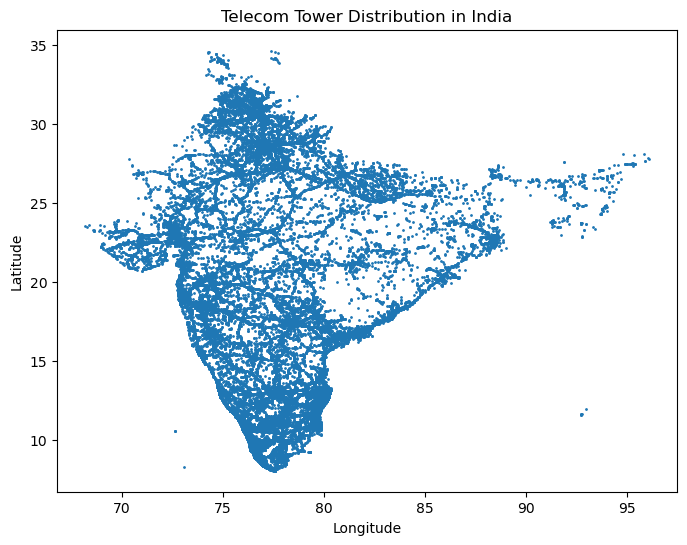

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df['long'], df['lat'], s=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Telecom Tower Distribution in India")

plt.show()

Observations:

***High Tower Density Regions***

South India (Tamil Nadu / Karnataka / Kerala)

Maharashtra region

Delhi–NCR region

Gujarat region

These areas appear dense because:

High population

High mobile usage,More telecom infrastructure

***Medium Density Regions***

Central India

Parts of Rajasthan

Odisha

Telangana

These areas have moderate tower coverage.

***Low Coverage Regions***

North-East India

Himalayan regions

Desert areas

Possible reasons:difficult terrain,lower population density,infrastructure limitations

In [143]:
# Prepare Data for Clustering
from sklearn.preprocessing import StandardScaler

X = df[['long','lat']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

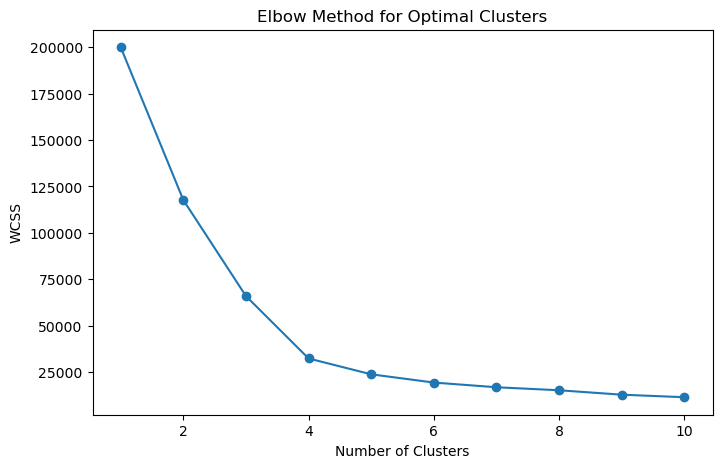

In [145]:
# Find Optimal Clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

K-Means requires number of clusters (k).

The elbow method helps determine: How many telecom coverage zones exist

In [149]:
# Train the K-Means Model

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,radio,mcc,mnc,lac,cid,long,lat,range,sample,radio_num,cluster
464908,GSM,404,71,2351,50955,75.635376,14.266434,1000,2,1,1
1553834,LTE,404,49,11011,231414529,78.377151,17.441483,1000,1,3,1
864004,UMTS,404,49,58002,20600969,82.241592,16.991959,1000,3,2,1
1735244,LTE,404,90,6032,216085507,73.775494,18.465093,1000,7,3,3
1507738,LTE,404,45,8100,536588,77.551804,12.975540,1000,2,3,1


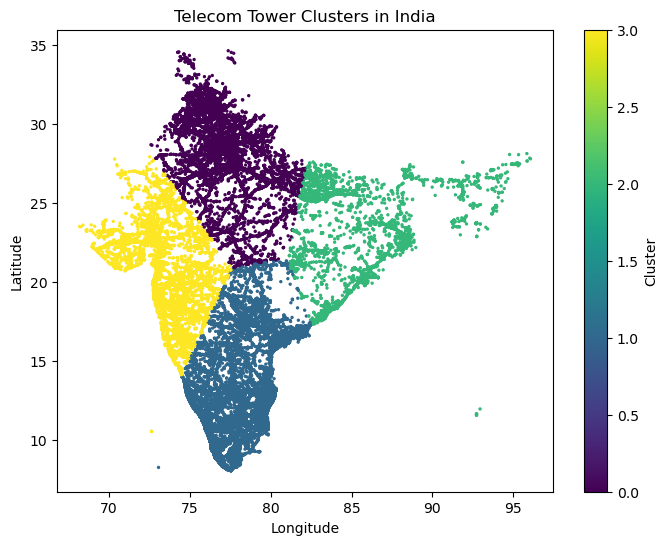

In [163]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(df['long'], df['lat'], c=df['cluster'], s=2)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Telecom Tower Clusters in India")

plt.colorbar(scatter,label="Cluster")

plt.show()

#### Approx interpretation:

| Cluster Color |	    Region	         |         Meaning                  |
| ------------- | ---------------------- | -------------------------------- |
| Purple        |	North India	         | Delhi, Punjab, Haryana, UP       |
| Yellow	    |    West India	         | Gujarat, Rajasthan, Maharashtra  |
| Blue	        |    South India	     | Karnataka, Tamil Nadu, Kerala    |
| Green	        |   East / North-East	 | Odisha, West Bengal, Assam       |

In [161]:
# Tower count per cluster

df['cluster'].value_counts()

cluster
1    40480
0    26710
3    23893
2     8916
Name: count, dtype: int64

>Cluster 1 has the highest number of towers.

Likely region → South India

Reasons : Very dense telecom infrastructure, Large urban population, Strong IT/industrial regions (Bangalore, Chennai, Hyderabad)

>Cluster 2 has the lowest towers.

Likely region → North-East / Eastern India

Reasons:difficult terrain, forest areas, lower population density, infrastructure challenges

In [165]:
# Network technology per cluster
pd.crosstab(df['cluster'], df['radio'])

radio,GSM,LTE,UMTS
cluster,,,
0,15143,2538,9029
1,21502,4940,14038
2,5898,384,2634
3,11793,3246,8854


***Observations***

GSM dominates everywhere

Most infrastructure still supports 2G networks.

This is realistic because many towers support multiple technologies.

Cluster 1 has strongest 4G infrastructure

Cluster 2 has weakest modern network

In [171]:
df.groupby('cluster')[['lat','long']].mean()

,lat,long
cluster,,
0,28.401237,77.191547
1,13.385367,78.063179
2,22.714765,86.408955
3,20.122179,73.391702


In [169]:
kmeans.cluster_centers_

array([[-0.07213577,  1.30149787],
       [ 0.16334163, -0.98008787],
       [ 2.41148048,  0.4370687 ],
       [-1.09525407,  0.0428491 ]])

In [175]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers

array([[77.19061864, 28.40519176],
       [78.06447159, 13.38581906],
       [86.40727963, 22.71477052],
       [73.39384268, 20.1196758 ]])

In [186]:
df['lat_bin'] = df['lat'].round(1)
df['long_bin'] = df['long'].round(1)

coverage = df.groupby(['lat_bin','long_bin']).size().reset_index(name='tower_count')

coverage.sort_values('tower_count').head(10)

,lat_bin,long_bin,tower_count
0,8.1,77.3,1
5228,22.1,79.7,1
5226,22.1,79.5,1
5223,22.1,78.2,1
5220,22.1,76.9,1
5219,22.1,76.8,1
5216,22.1,75.8,1
5215,22.1,75.7,1
5214,22.1,75.5,1
5213,22.1,74.9,1


>This will show locations with lowest tower density.

>These are potential network expansion zones.

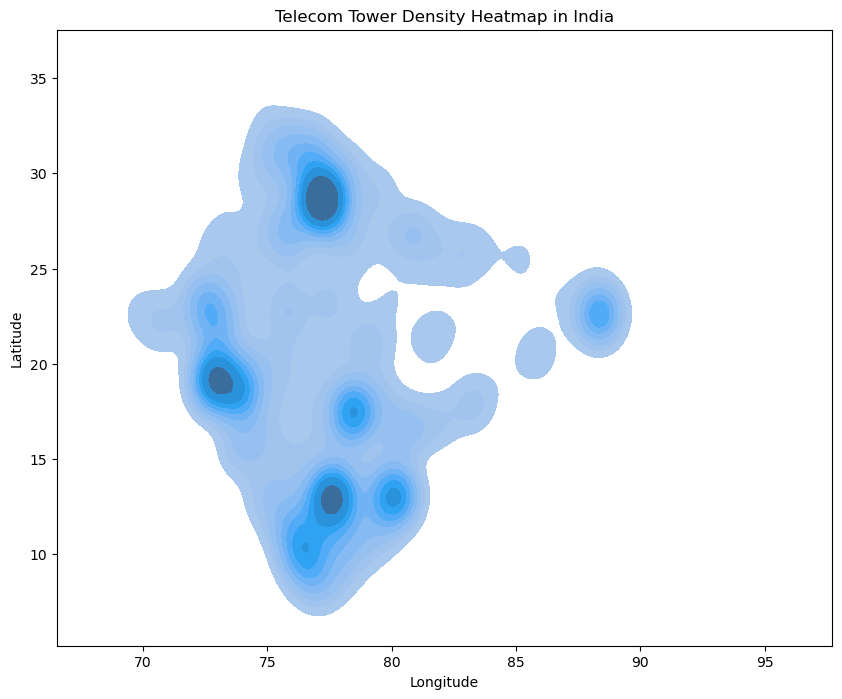

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.kdeplot(
    x=df['long'],
    y=df['lat'],
    fill=True
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Telecom Tower Density Heatmap in India")

plt.show()

##### Dark regions = high tower density

Likely:

>South India

>Maharashtra

>Delhi region

In [195]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [197]:
import folium

# Create base map
india_map = folium.Map(location=[20,78], zoom_start=5)

# Sample small subset (important for performance)
sample_df = df.sample(2000)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=2
    ).add_to(india_map)

india_map

#### Identifying Potential Locations for Telecom Infrastructure Expansion

In [203]:
df['lat_grid'] = df['lat'].round(1)
df['lon_grid'] = df['long'].round(1)

grid_density = df.groupby(['lat_grid','lon_grid']).size().reset_index(name='tower_count')

grid_density.head()
# This counts how many towers exist in each small geographic cell.

,lat_grid,lon_grid,tower_count
0,8.1,77.3,1
1,8.1,77.4,8
2,8.1,77.5,7
3,8.1,77.6,10
4,8.2,77.2,1


In [205]:
low_coverage = grid_density.sort_values('tower_count').head(20)

low_coverage

,lat_grid,lon_grid,tower_count
0,8.1,77.3,1
5228,22.1,79.7,1
5226,22.1,79.5,1
5223,22.1,78.2,1
5220,22.1,76.9,1
5219,22.1,76.8,1
5216,22.1,75.8,1
5215,22.1,75.7,1
5214,22.1,75.5,1
5213,22.1,74.9,1


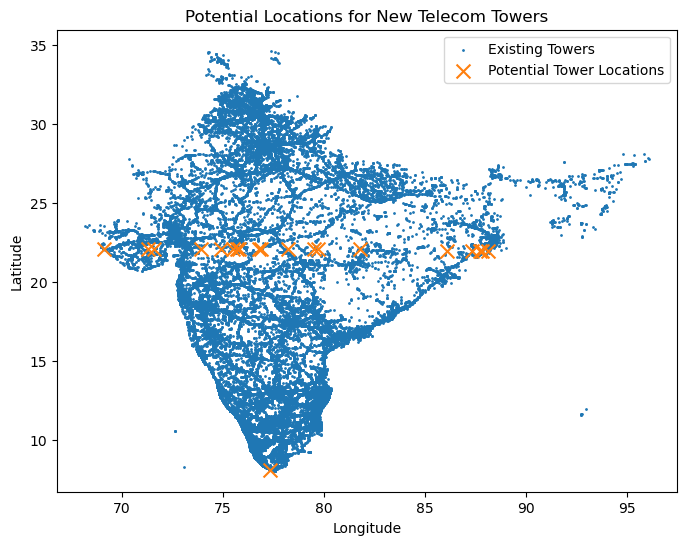

In [207]:
plt.figure(figsize=(8,6))

plt.scatter(df['long'], df['lat'], s=1, label="Existing Towers")

plt.scatter(low_coverage['lon_grid'], low_coverage['lat_grid'],
            marker='x', s=100, label="Potential Tower Locations")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Potential Locations for New Telecom Towers")

plt.legend()

plt.show()

In [ ]:
### Using folium , For better visualization 

In [209]:
import folium

# create map centered on India
map_india = folium.Map(location=[20,78], zoom_start=5)

# sample towers for performance
sample_existing = df.sample(2000)

# existing towers
for _, row in sample_existing.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=2,
        color="blue",
        fill=True,
        fill_opacity=0.6
    ).add_to(map_india)

# potential new tower locations
for _, row in low_coverage.iterrows():
    folium.Marker(
        location=[row['lat_grid'], row['lon_grid']],
        icon=folium.Icon(color="red", icon="signal", prefix="fa"),
        popup="Potential Tower Location"
    ).add_to(map_india)

map_india